Tahap (1) Memuat Dataset

In [1]:
# =========================================
# IMPORT LIBRARY
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# LOAD DATASET HASIL PREPROCESSING
# =========================================

df_cuaca = pd.read_csv("dataset_bmkg.csv")

display(df_cuaca.head())

,datetime,wilayah,adm4,suhu,kelembapan,curah_hujan,kecepatan_angin
0,2026-05-24 00:00:00,Babakan,36.03.20.1011,24,96,0.0,5.6
1,2026-05-24 03:00:00,Babakan,36.03.20.1011,24,98,0.0,3.2
2,2026-05-24 06:00:00,Babakan,36.03.20.1011,26,98,0.0,5.0
3,2026-05-24 09:00:00,Babakan,36.03.20.1011,29,73,0.0,4.3
4,2026-05-24 12:00:00,Babakan,36.03.20.1011,32,85,3.8,7.5


Tahap (2) Struktur Data dan Tipe Variabel

In [2]:
# =========================================
# STRUKTUR DATA DAN TIPE VARIABEL
# =========================================

print("Ukuran Dataset:")
print(df_cuaca.shape)

print("\nInformasi Dataset:")
df_cuaca.info()

print("\nTipe Data:")
print(df_cuaca.dtypes)

Ukuran Dataset:
(532, 7)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   datetime         532 non-null    object 
 1   wilayah          532 non-null    object 
 2   adm4             532 non-null    object 
 3   suhu             532 non-null    int64  
 4   kelembapan       532 non-null    int64  
 5   curah_hujan      532 non-null    float64
 6   kecepatan_angin  532 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 29.2+ KB

Tipe Data:
datetime            object
wilayah             object
adm4                object
suhu                 int64
kelembapan           int64
curah_hujan        float64
kecepatan_angin    float64
dtype: object


Tahap (3) Statistik Deskriptif

In [3]:
# =========================================
# STATISTIK DESKRIPTIF
# =========================================

display(df_cuaca.describe())

,suhu,kelembapan,curah_hujan,kecepatan_angin
count,532.000000,532.000000,532.00000,532.000000
mean,26.208647,89.607143,0.42500,5.383647
std,2.360153,8.384239,0.97654,3.177412
min,23.000000,67.000000,0.00000,0.200000
25%,24.000000,86.000000,0.00000,2.800000
50%,25.000000,93.000000,0.00000,4.800000
75%,28.000000,96.000000,0.10000,7.400000
max,32.000000,99.000000,4.10000,17.100000


Tahap (4) Visualisasi Data

4A → Histogram

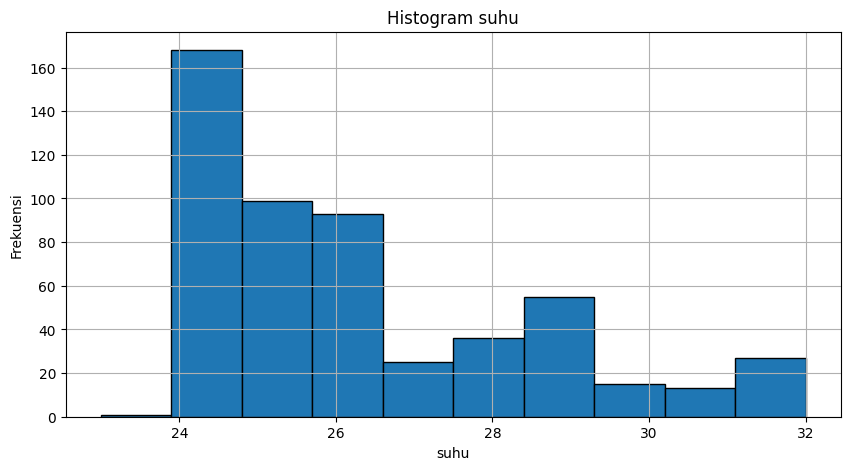

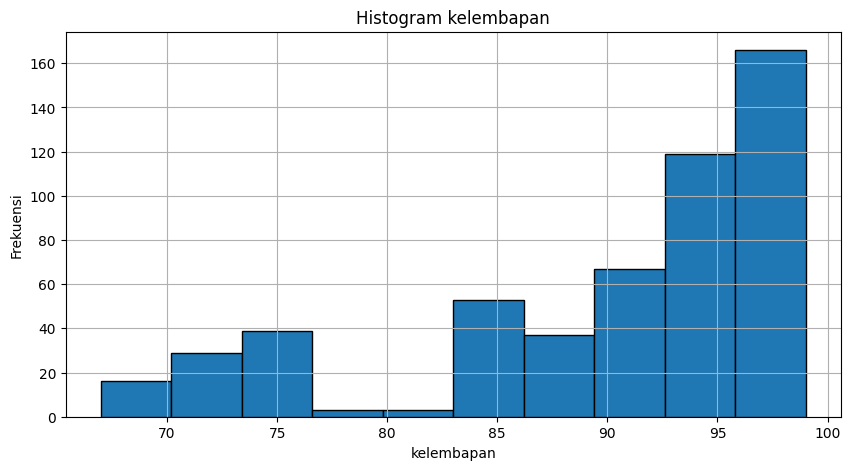

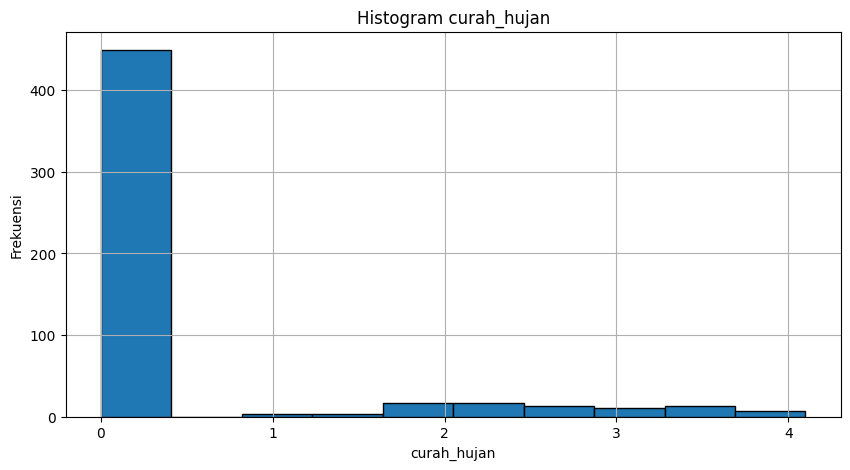

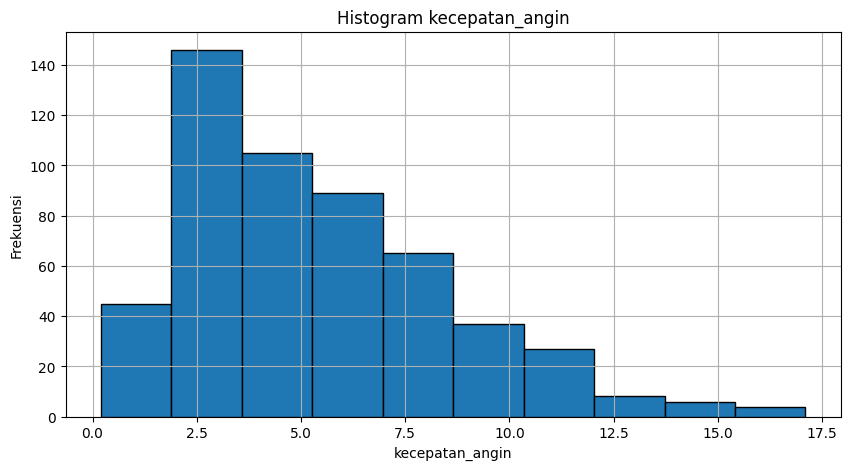

In [4]:
# =========================================
# HISTOGRAM
# =========================================

kolom = [
    "suhu",
    "kelembapan",
    "curah_hujan",
    "kecepatan_angin"
]

for item in kolom:

    plt.figure(figsize=(10,5))

    plt.hist(
        df_cuaca[item],
        bins=10,
        edgecolor='black'
    )

    plt.title(
        f"Histogram {item}"
    )

    plt.xlabel(item)

    plt.ylabel("Frekuensi")

    plt.grid()

    plt.show()

4B → Grafik Time Series Suhu


Jumlah titik waktu: 19
Periode awal: 2026-05-24 00:00:00
Periode akhir: 2026-05-26 06:00:00


,datetime,suhu
0,2026-05-24 00:00:00,24.035714
1,2026-05-24 03:00:00,24.035714
2,2026-05-24 06:00:00,25.964286
3,2026-05-24 09:00:00,29.000000
4,2026-05-24 12:00:00,31.892857
5,2026-05-24 15:00:00,27.964286
6,2026-05-24 18:00:00,26.000000
7,2026-05-24 21:00:00,25.000000
8,2026-05-25 00:00:00,24.142857
9,2026-05-25 03:00:00,24.035714


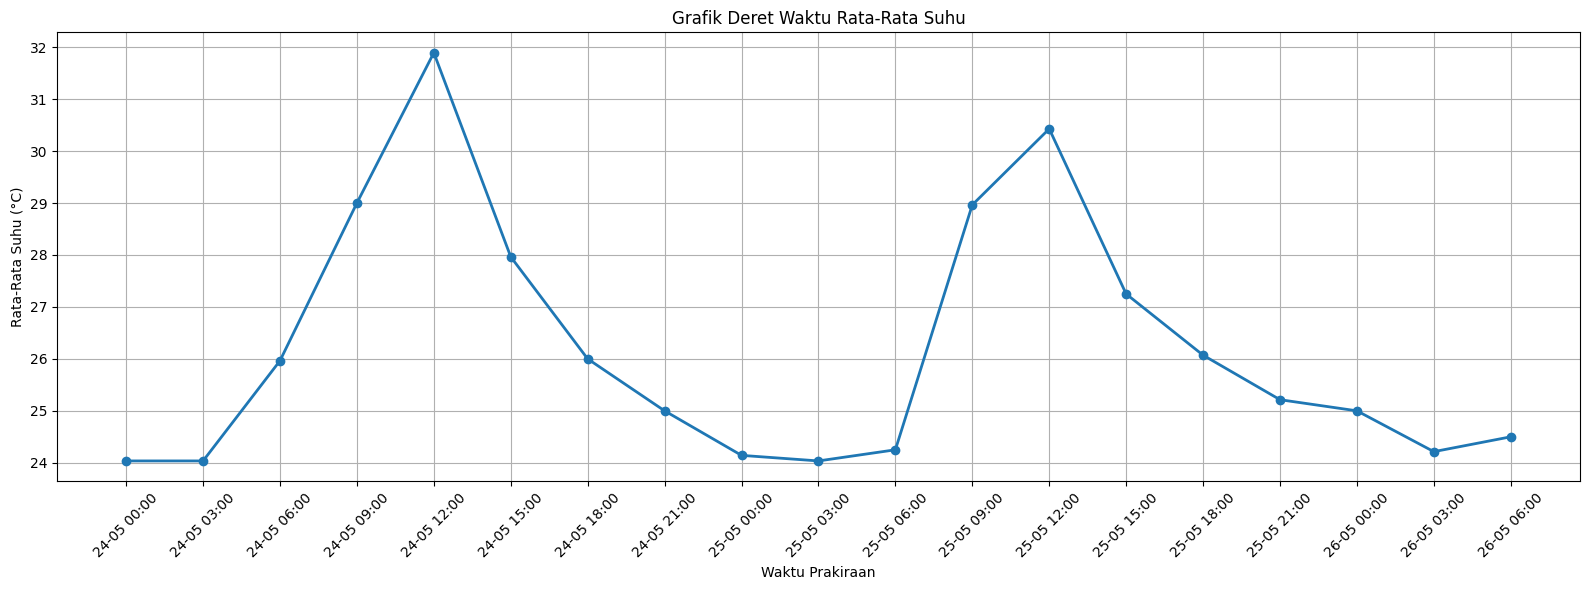

In [5]:
# =========================================
# GRAFIK TIME SERIES SUHU
# =========================================

# Membuat salinan dataframe agar data asli tetap aman
df_timeseries_suhu = df_cuaca.copy()

# Mengubah kolom datetime menjadi tipe data datetime
# Proses ini diperlukan agar data dapat dibaca sebagai data deret waktu
df_timeseries_suhu["datetime"] = pd.to_datetime(
    df_timeseries_suhu["datetime"]
)

# Mengurutkan data berdasarkan waktu pengamatan
# Pengurutan waktu penting dalam analisis time series
df_timeseries_suhu = df_timeseries_suhu.sort_values(
    by="datetime"
)

# Menghitung rata-rata suhu pada setiap waktu pengamatan
# Dataset memiliki beberapa wilayah, sehingga suhu dirata-ratakan per datetime
df_suhu_ts = df_timeseries_suhu.groupby(
    "datetime",
    as_index=False
)["suhu"].mean()

# Menampilkan informasi ringkas hasil agregasi
print("Jumlah titik waktu:", len(df_suhu_ts))
print("Periode awal:", df_suhu_ts["datetime"].min())
print("Periode akhir:", df_suhu_ts["datetime"].max())

# Menampilkan tabel time series suhu
display(df_suhu_ts)

# =========================================
# VISUALISASI TIME SERIES SUHU
# =========================================

# Mengatur ukuran grafik
plt.figure(
    figsize=(16, 6)
)

# Membuat grafik garis suhu terhadap waktu
plt.plot(
    df_suhu_ts["datetime"],
    df_suhu_ts["suhu"],
    marker="o",
    linewidth=2
)

# Memberikan judul grafik
plt.title(
    "Grafik Deret Waktu Rata-Rata Suhu"
)

# Memberikan label sumbu X
plt.xlabel(
    "Waktu Prakiraan"
)

# Memberikan label sumbu Y
plt.ylabel(
    "Rata-Rata Suhu (°C)"
)

# Mengatur format label waktu pada sumbu X
plt.xticks(
    df_suhu_ts["datetime"],
    df_suhu_ts["datetime"].dt.strftime("%d-%m %H:%M"),
    rotation=45
)

# Menampilkan grid agar grafik lebih mudah dibaca
plt.grid()

# Mengatur tata letak agar label tidak terpotong
plt.tight_layout()

# Menyimpan gambar agar dapat dimasukkan ke dokumen skripsi
plt.savefig(
    "grafik_time_series_suhu.png",
    dpi=300,
    bbox_inches="tight"
)

# Menampilkan grafik
plt.show()

4C → Boxplot

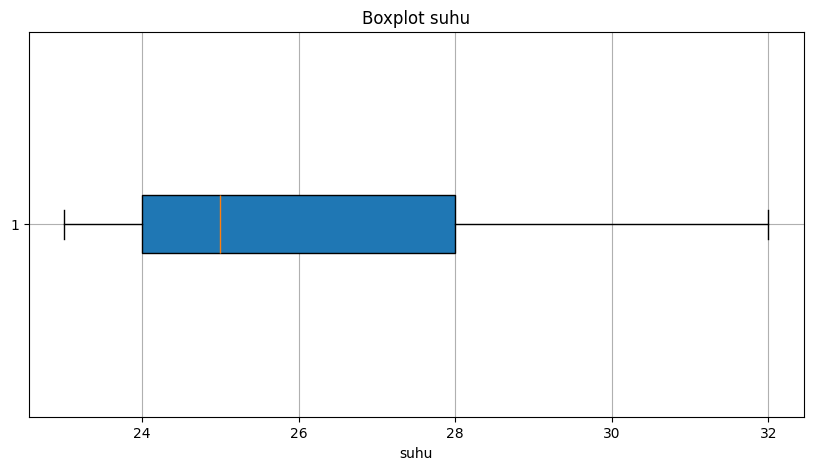

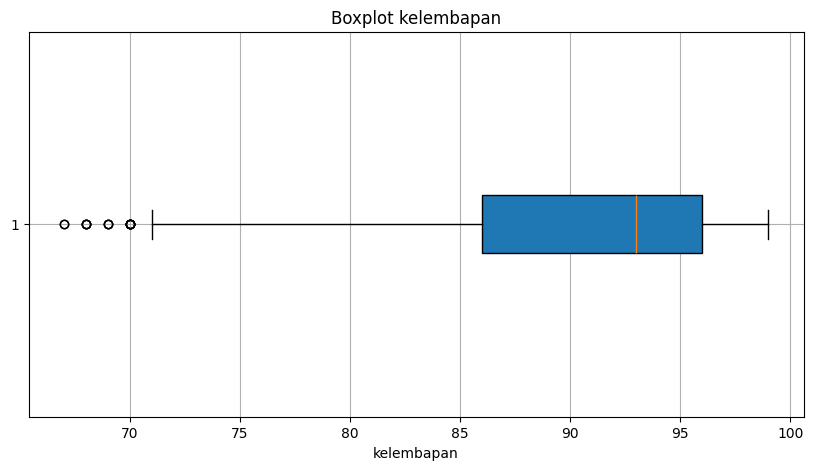

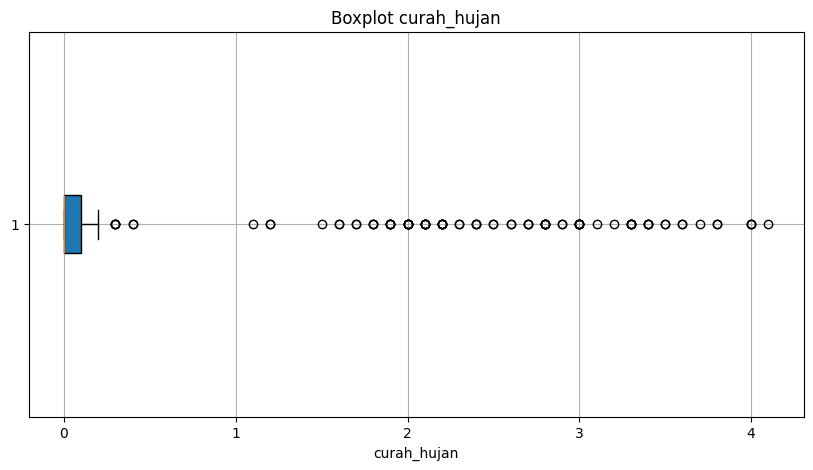

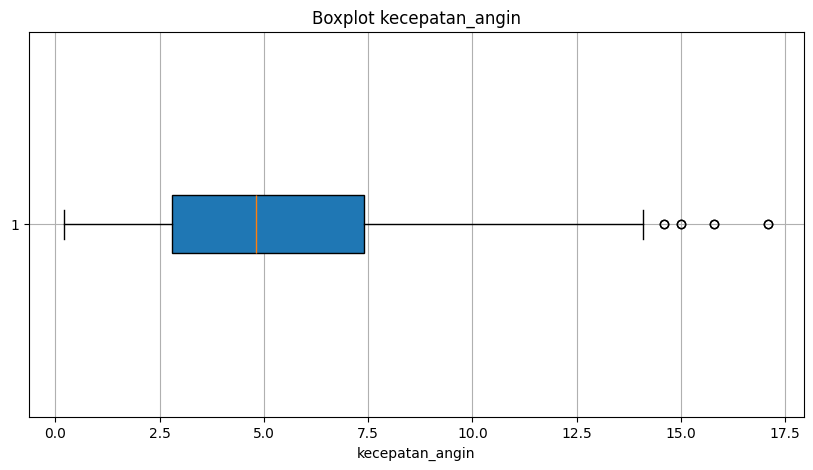

In [6]:
# =========================================
# BOXPLOT
# =========================================

kolom = [
    "suhu",
    "kelembapan",
    "curah_hujan",
    "kecepatan_angin"
]

for item in kolom:

    plt.figure(figsize=(10,5))

    plt.boxplot(
        df_cuaca[item],
        vert=False,
        patch_artist=True
    )

    plt.title(
        f"Boxplot {item}"
    )

    plt.xlabel(item)

    plt.grid()

    plt.show()

4D → Scatter Plot

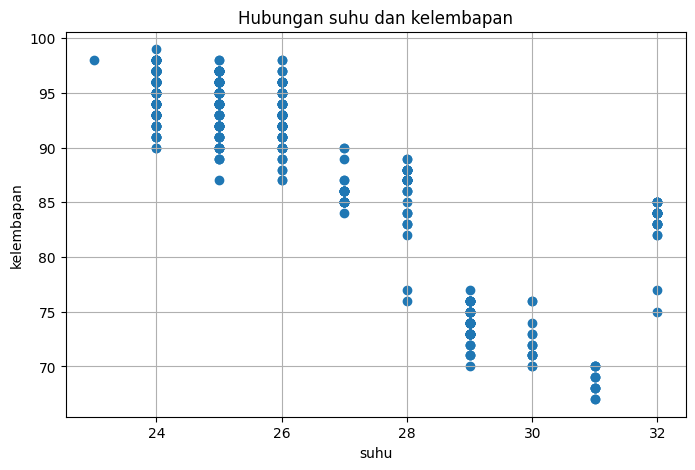

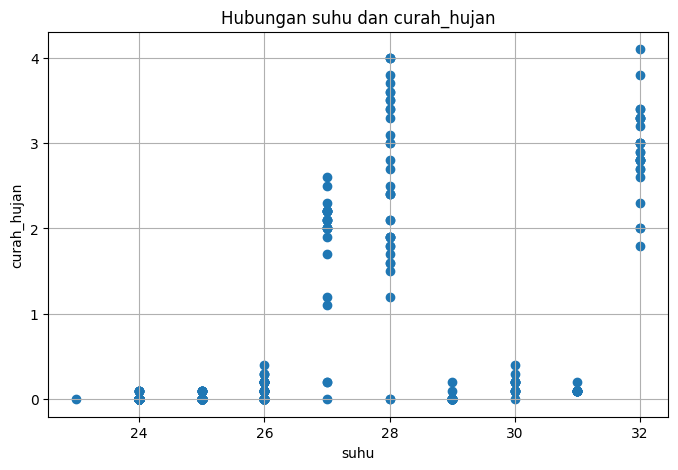

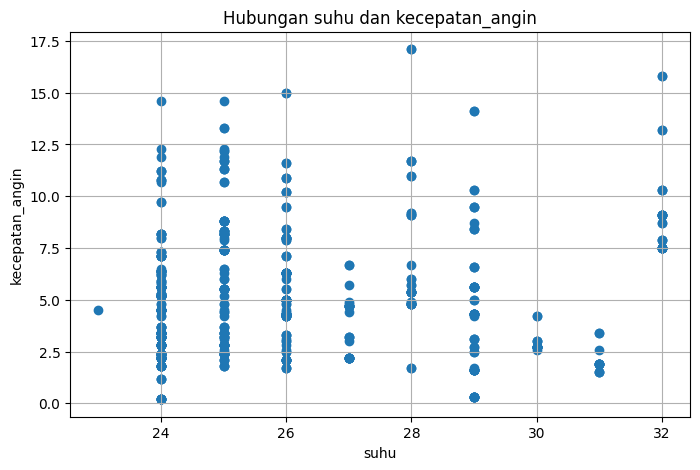

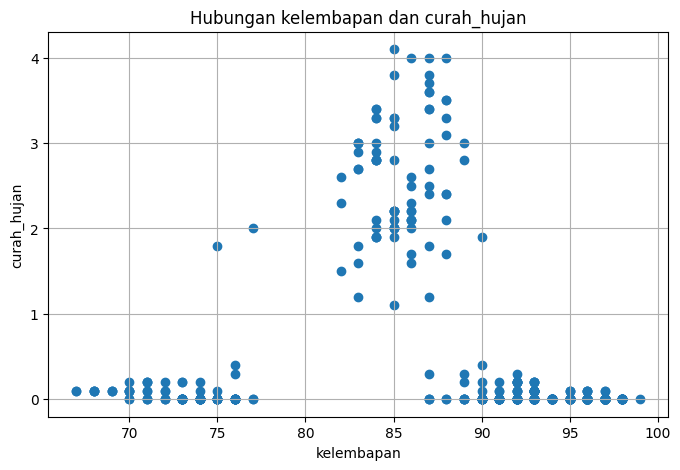

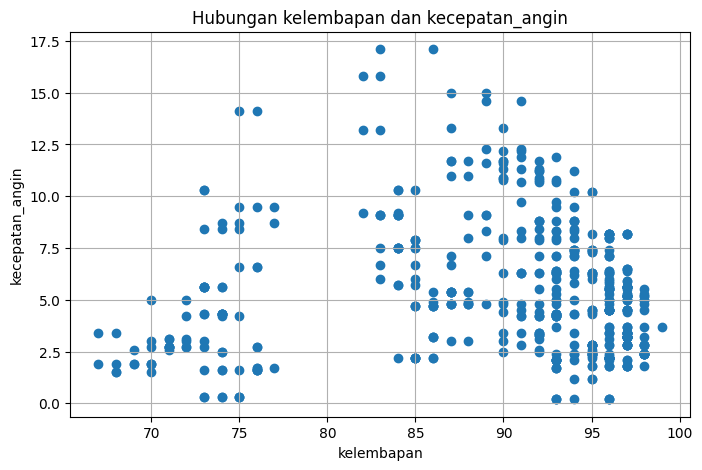

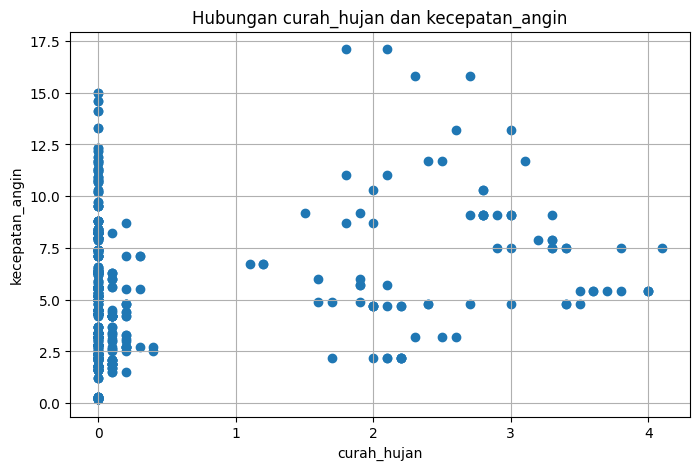

In [7]:
# =========================================
# SCATTER PLOT ANTAR VARIABEL
# =========================================

kolom = [
    "suhu",
    "kelembapan",
    "curah_hujan",
    "kecepatan_angin"
]

for i in range(len(kolom)):

    for j in range(i+1,len(kolom)):

        plt.figure(figsize=(8,5))

        plt.scatter(
            df_cuaca[kolom[i]],
            df_cuaca[kolom[j]]
        )

        plt.title(
            f"Hubungan {kolom[i]} dan {kolom[j]}"
        )

        plt.xlabel(
            kolom[i]
        )

        plt.ylabel(
            kolom[j]
        )

        plt.grid()

        plt.show()

4E → Heatmap

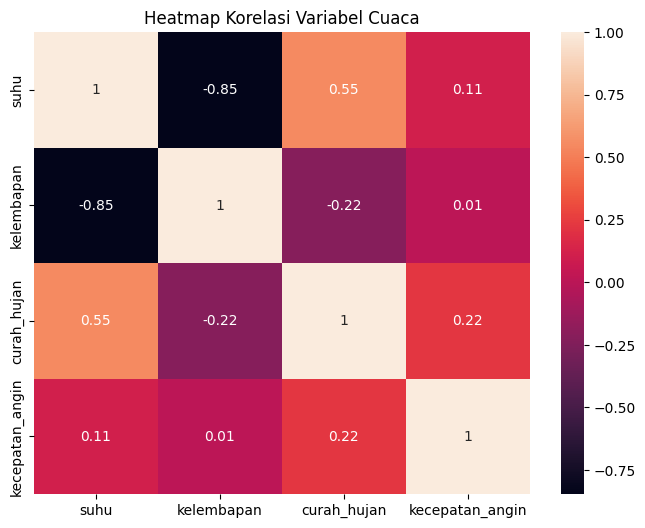

In [8]:
# =========================================
# IMPORT LIBRARY
# =========================================

import seaborn as sns

# =========================================
# HEATMAP KORELASI
# =========================================

korelasi = df_cuaca[
[
"suhu",
"kelembapan",
"curah_hujan",
"kecepatan_angin"
]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    korelasi,
    annot=True
)

plt.title(
    "Heatmap Korelasi Variabel Cuaca"
)

plt.show()

Tahap (5) Pemeriksaan Outlier dan Missing Value

5A → Missing Value

In [9]:
# =========================================
# MISSING VALUE
# =========================================

print(df_cuaca.isnull().sum())

datetime           0
wilayah            0
adm4               0
suhu               0
kelembapan         0
curah_hujan        0
kecepatan_angin    0
dtype: int64


5B → Outlier (IQR)

In [10]:
# =========================================
# DETEKSI OUTLIER MENGGUNAKAN IQR
# =========================================

kolom = [
    "suhu",
    "kelembapan",
    "curah_hujan",
    "kecepatan_angin"
]

for item in kolom:

    Q1 = df_cuaca[item].quantile(0.25)

    Q3 = df_cuaca[item].quantile(0.75)

    IQR = Q3-Q1

    batas_bawah = Q1-(1.5*IQR)

    batas_atas = Q3+(1.5*IQR)

    outlier = df_cuaca[
        (df_cuaca[item] < batas_bawah) |
        (df_cuaca[item] > batas_atas)
    ]

    print("\n===================")

    print("Variabel:",item)

    print("Jumlah Outlier:",len(outlier))


Variabel: suhu
Jumlah Outlier: 0

Variabel: kelembapan
Jumlah Outlier: 16

Variabel: curah_hujan
Jumlah Outlier: 89

Variabel: kecepatan_angin
Jumlah Outlier: 8


Tahap (6) Korelasi Antar Fitur

In [11]:
# =========================================
# KORELASI
# =========================================

korelasi=df_cuaca[
[
"suhu",
"kelembapan",
"curah_hujan",
"kecepatan_angin"
]
].corr()

display(korelasi)

,suhu,kelembapan,curah_hujan,kecepatan_angin
suhu,1.000000,-0.846673,0.547641,0.10628
kelembapan,-0.846673,1.000000,-0.222992,0.01044
curah_hujan,0.547641,-0.222992,1.000000,0.22176
kecepatan_angin,0.106280,0.010440,0.221760,1.00000


Tahap (7) Insight Awal

In [12]:
# =========================================
# TAHAP (7)
# INSIGHT DAN KESIMPULAN AWAL
# =========================================

print("""

1. Dataset hasil preprocessing terdiri dari
   532 baris data dan 7 atribut penelitian.

2. Hasil pemeriksaan missing value menunjukkan
   bahwa dataset tidak memiliki nilai kosong
   sehingga data dapat digunakan pada tahap
   pemodelan.

3. Hasil visualisasi histogram dan boxplot
   menunjukkan bahwa variabel suhu,
   kelembapan, curah_hujan, dan
   kecepatan_angin memiliki distribusi data
   yang berbeda pada setiap variabel.

4. Hasil deteksi outlier menggunakan metode
   Interquartile Range (IQR) menunjukkan bahwa
   variabel suhu tidak memiliki outlier,
   sedangkan variabel kelembapan memiliki
   16 outlier, curah_hujan memiliki
   89 outlier, dan kecepatan_angin memiliki
   8 outlier.

5. Jumlah outlier yang relatif tinggi pada
   variabel curah_hujan dapat terjadi karena
   karakteristik data cuaca yang memiliki
   variasi nilai cukup besar pada periode
   tertentu.

6. Hasil analisis korelasi menunjukkan bahwa
   suhu memiliki hubungan negatif yang kuat
   terhadap kelembapan sebesar -0.846673.

7. Hasil analisis korelasi menunjukkan bahwa
   suhu memiliki hubungan positif sedang
   terhadap curah_hujan sebesar 0.547641,
   sedangkan kecepatan_angin memiliki
   hubungan yang relatif rendah terhadap
   variabel lainnya.

8. Hasil EDA menunjukkan bahwa dataset telah
   memiliki kualitas data yang baik dan siap
   digunakan pada tahap pemodelan forecasting
   menggunakan metode ARIMA dan Prophet.

""")



1. Dataset hasil preprocessing terdiri dari
   532 baris data dan 7 atribut penelitian.

2. Hasil pemeriksaan missing value menunjukkan
   bahwa dataset tidak memiliki nilai kosong
   sehingga data dapat digunakan pada tahap
   pemodelan.

3. Hasil visualisasi histogram dan boxplot
   menunjukkan bahwa variabel suhu,
   kelembapan, curah_hujan, dan
   kecepatan_angin memiliki distribusi data
   yang berbeda pada setiap variabel.

4. Hasil deteksi outlier menggunakan metode
   Interquartile Range (IQR) menunjukkan bahwa
   variabel suhu tidak memiliki outlier,
   sedangkan variabel kelembapan memiliki
   16 outlier, curah_hujan memiliki
   89 outlier, dan kecepatan_angin memiliki
   8 outlier.

5. Jumlah outlier yang relatif tinggi pada
   variabel curah_hujan dapat terjadi karena
   karakteristik data cuaca yang memiliki
   variasi nilai cukup besar pada periode
   tertentu.

6. Hasil analisis korelasi menunjukkan bahwa
   suhu memiliki hubungan negatif yang kuat
   terhadap kelembap